# LOGISTIC REGRESSION

## 1. Data Exploration:
#### a. Load the dataset and perform exploratory data analysis (EDA).
#### b. Examine the features, their types, and summary statistics.
#### c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
#### Analyze any patterns or correlations observed in the data.


In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetes.csv")

# Basic info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


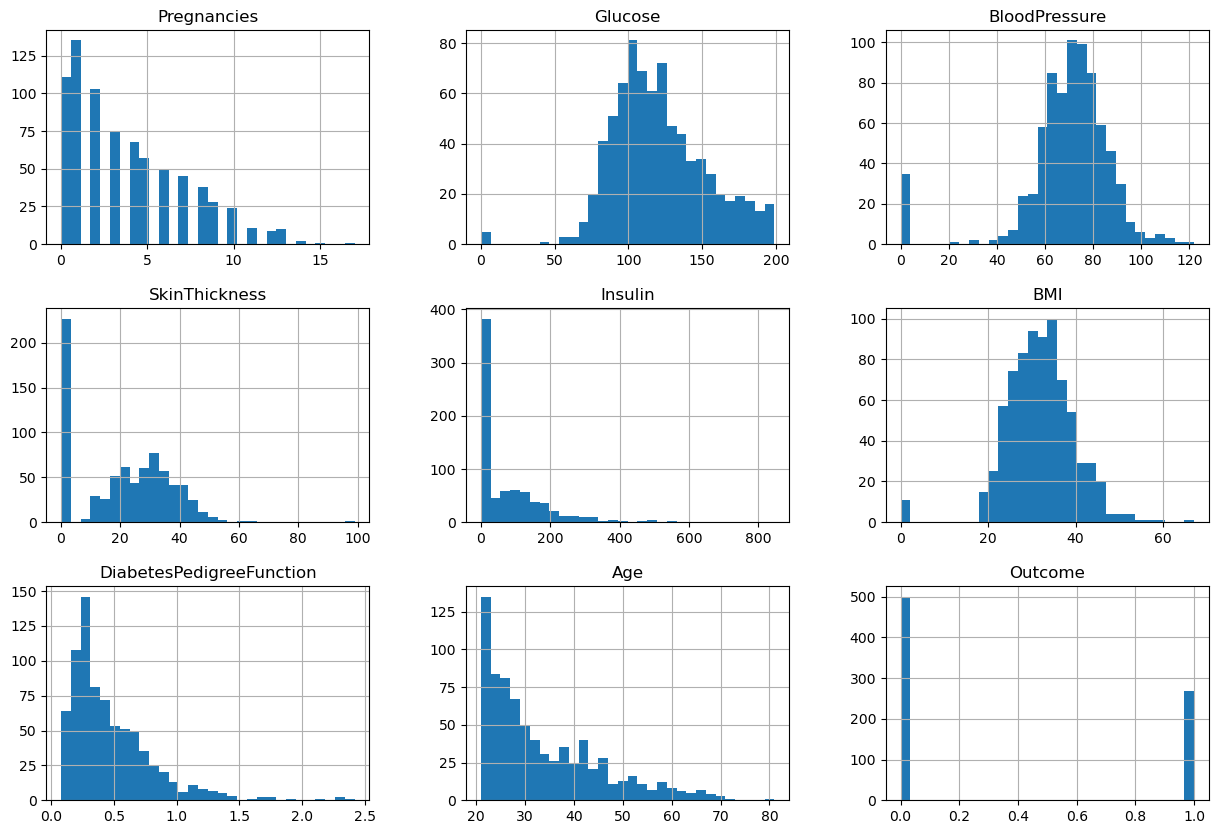

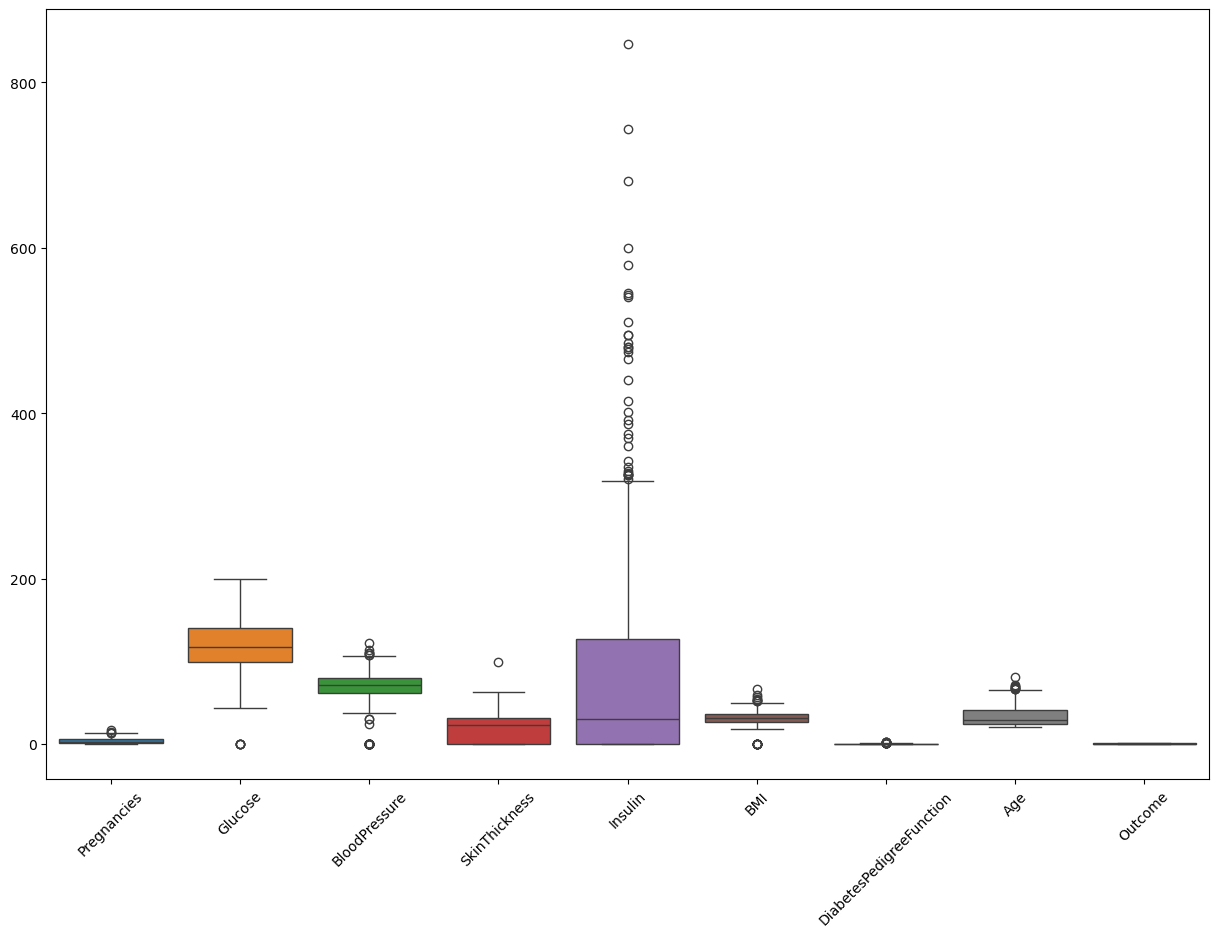

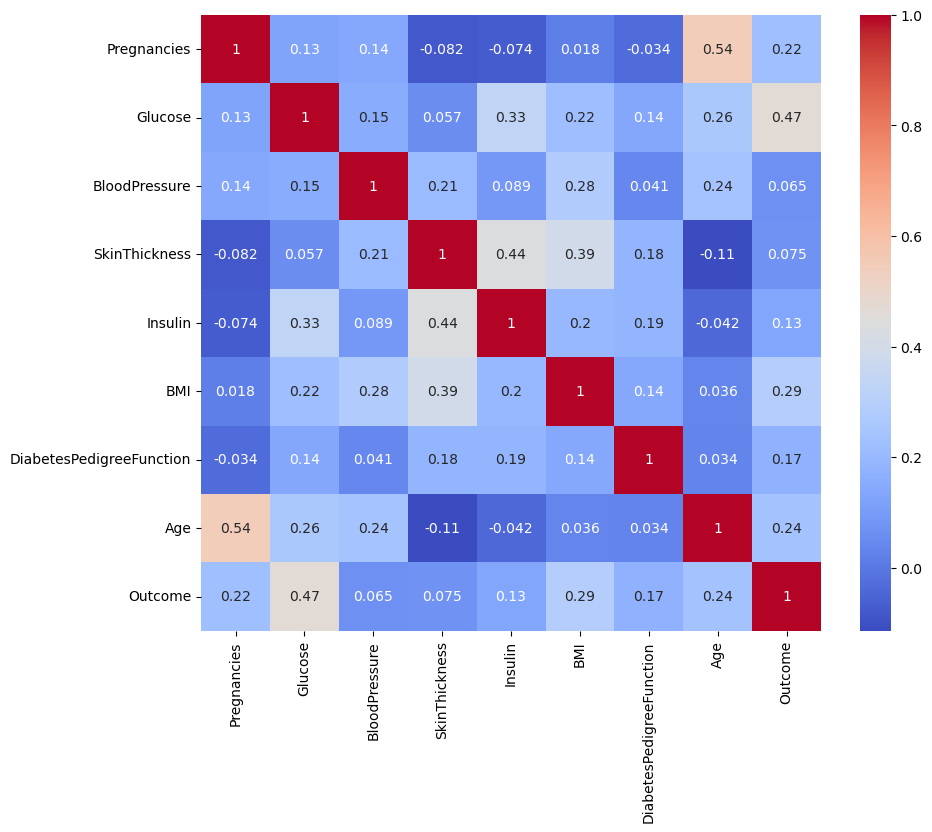

In [2]:
# Check for missing values
df.isnull().sum()

# Histograms
df.hist(bins=30, figsize=(15,10))
plt.show()

# Boxplots
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# 2. Data Preprocessing:
### a. Handle missing values (e.g., imputation).
### b. Encode categorical variables.



In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Replace zeros with np.nan in selected columns
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Evaluation

Accuracy: 0.7532467532467533
Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1 Score: 0.6415094339622641
ROC-AUC: 0.8211202938475666


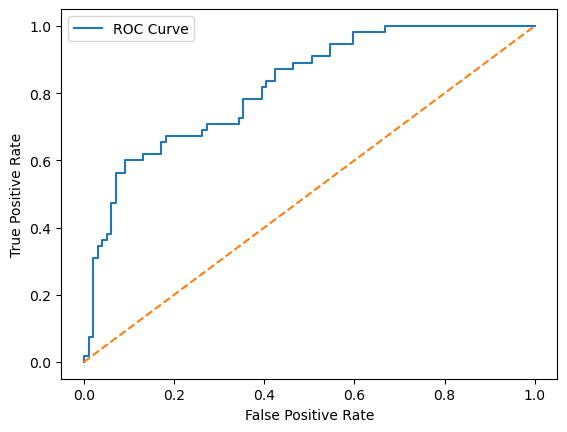

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Interpretation

In [6]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                    Feature  Coefficient
6  DiabetesPedigreeFunction     0.553774
5                       BMI     0.101803
0               Pregnancies     0.067595
1                   Glucose     0.037338
7                       Age     0.034614
3             SkinThickness     0.007706
4                   Insulin    -0.001669
2             BloodPressure    -0.013234


## Deployment with Streamlit

In [1]:
pip install streamlit


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import pickle

df = pd.read_csv("diabetes.csv")

cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [3]:
cd Desktop\DiabetesApp


[WinError 3] The system cannot find the path specified: 'Desktop\\DiabetesApp'
C:\Users\praga


In [ ]:
!streamlit run app.py

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import pickle

# Load dataset
df = pd.read_csv("diabetes.csv")

# Replace zeros with np.nan
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Impute missing values
imputer = SimpleImputer(strategy='median')
df[cols_with_zero] = imputer.fit_transform(df[cols_with_zero])

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Save model
with open("diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
import streamlit as st
import pickle

# Load trained model
model = pickle.load(open("diabetes_model.pkl","rb"))

st.title("Diabetes Prediction App")

preg = st.number_input("Pregnancies", 0, 20, 1)
glucose = st.number_input("Glucose", 0, 200, 100)
bp = st.number_input("Blood Pressure", 0, 150, 70)
skin = st.number_input("Skin Thickness", 0, 100, 20)
insulin = st.number_input("Insulin", 0, 900, 80)
bmi = st.number_input("BMI", 0.0, 70.0, 25.0)
dpf = st.number_input("Diabetes Pedigree Function", 0.0, 2.5, 0.5)
age = st.number_input("Age", 0, 100, 30)

features = [[preg, glucose, bp, skin, insulin, bmi, dpf, age]]
prediction = model.predict(features)

st.write("Prediction:", "Diabetic" if prediction[0]==1 else "Non-Diabetic")

##  Interview Question Answers
These answers are tailored to your current Data Science and AI internship goals:

Q1: What is the difference between precision and recall?
Precision: Focuses on the accuracy of positive predictions. It asks: "Of all patients predicted as diabetic, how many actually are?" It is important when the cost of a "False Positive" is high.

Recall: Focuses on capturing all positive cases. It asks: "Of all patients who are actually diabetic, how many did the model find?" In medical diagnosis, recall is usually more critical to avoid missing a sick patient.

Q2: What is cross-validation, and why is it important in binary classification?
Definition: Cross-validation is a technique where the dataset is split into multiple subsets (folds). The model is trained on some folds and tested on the remaining one, rotating this process until every fold has been used as a test set.

Importance: It provides a more reliable estimate of model performance than a single train-test split. It helps ensure that the model generalizes well to new data and isn't just "overfitting" to one specific portion of your training set.